In [2]:
import os
os.chdir('../')

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from utils.vis_utils import get_selfplay_scores, vis_cross_play_matrix, plot_sp_by_xp, \
    get_selfplay_scores, get_ood_gen_scores
    # vis_nk_curve,
# reload modules
%load_ext autoreload
%autoreload 2

In [3]:
base_path = "naht_results"

## Visualize Results Tables

In [ ]:

algorithms = {  # format is alg log name: display name      
    "vdn": "vdn", 
    "qmix": "qmix",
    "iql": "iql",
    "ippo": "ippo", 
    "mappo": "mappo", 
    "poam": "poam-aht",
    "ippo-naht": "ippo-naht",
    "poam": "poam",
}

n_runs = 5
for log_folder, n_agents in {
    "mpe-pp/ts=100_shape=0.01": 3, 
    "5v6": 5, 
    "8v9": 8, 
    "10v11": 10,
    "3s5z": 3,
}.items():
    print("Setting: ", log_folder)
    df = vis_cross_play_matrix(log_path=os.path.join(base_path, log_folder, "open_eval_best"), 
                               algorithms=algorithms,
                               # algs to compute the xp score with
                               eval_algs=["vdn", "qmix", "iql", "ippo", "mappo"], # TODO: enable specifying the seed of teammate as well
                               n_expected_evals=n_runs*(n_agents - 1),
                               vis_table_colors=True,
                               rm_empty_evals=True,
                               rm_duplicates=True,
                               save=True,
                               savedir="../../open_marl_results/figures/5trials-95ci",
                               savename=f"{log_folder.replace('/', '_')}_xp-matrix.png", 
                               verbose=True
                               )
    
    display(df)
    # plot_sp_by_xp(df, algorithms, xp_col_name="XP score (mean +/- std)",
    #               task=log_folder, legend_loc=(0.85, -0.25))

print("Note: all scores are the mean +/- 95% CI")

## Matched vs Mismatched Seeds for Self Play

In [ ]:
normalize = True
base_path = "/scratch/cluster/clw4542/explore_marl/open_marl_results/"
algorithms = [        
    "vdn",
    "qmix",
    "iql",
    "ippo", 
    "mappo", 
]
n_runs = 5
for log_folder, n_agents in {
    "5v6": 5, 
    "8m": 8,
    "8v9": 8, 
    "3s5z": 3,
    "mpe-pp/ts=100_shape=0.01": 3
}.items():
    print("Setting: ", log_folder)
    # std ERRORS
    sp_scores_matched_means, sp_scores_matched_cis = get_selfplay_scores(log_path=os.path.join(base_path, log_folder, "open_eval_best"), 
                                    algorithms=algorithms,
                                    n_expected_evals=n_runs*(n_agents - 1),
                                    remove_empty_evals=False,
                                    require_matched_seeds=False)
    sp_scores_mismatched_means, sp_scores_mismatched_cis  = get_selfplay_scores(log_path=os.path.join(base_path, log_folder, "selfplay_mismatched_eval_best"),
                                    algorithms=algorithms,
                                    n_expected_evals=n_runs*(n_agents - 1),
                                    remove_empty_evals=False,
                                    require_matched_seeds=False)
    
    # plot double bar chart of sp_scores_matched and sp_scores_mismatched. Both dicts have the same keys 
    # (algorithms) and values (means and stds of self-play scores across runs)

    fig, ax = plt.subplots()
    s1 = pd.Series(sp_scores_matched_means, name='matched')
    s2 = pd.Series(sp_scores_mismatched_means, name='mismatched')
    
    sp_df = pd.concat([s1, s2], axis=1)
    sp_df.columns = ['matched', 'mismatched']
    bars = sp_df.plot(kind='bar', ax=ax)

    # Calculate the x positions for the matched and mismatched groups
    bar_width = bars.patches[0].get_width()
    n_bars = len(sp_df)
    indices = range(n_bars)
    x_positions_matched = [bar.get_x() + bar_width/2 for bar in bars.patches[:n_bars]]
    x_positions_mismatched = [bar.get_x() + bar_width * 1.5 for bar in bars.patches[:n_bars]]

    # Add error bars
    ax.errorbar(x_positions_matched, sp_scores_matched_means.values(), 
               yerr=sp_scores_matched_cis.values(), 
               fmt='none', capsize=5, color='black')
    ax.errorbar(x_positions_mismatched, sp_scores_mismatched_means.values(), 
                yerr=sp_scores_mismatched_cis.values(), 
                fmt='none', capsize=5, color='black')

    # tilt x axis tick labels 
    plt.xticks(rotation=45)
    ax.set_ylabel("Mean self-play score")
    ax.set_xlabel("Algorithm")
    ax.set_title(f"Self-play scores for {log_folder}")
    plt.legend(loc="upper right")
    plt.show()


# OOD Generalization Evaluation

In [ ]:
base_path = "/scratch/cluster/clw4542/explore_marl/open_marl_results/"
exp_namemap = { # format is alg log name: display name
        "ippo-aht": "ippo aht",
        "poam-aht": "poam aht",
        "ippo-naht": "ippo naht",
        "poam": "poam",
}

target_algs = [        
    "vdn", 
    "qmix",
    "iql",
    "ippo", 
    "mappo", 
]

n_eval_alg_seeds = 3
n_target_alg_seeds = 2
for log_folder, algs_to_eval in {
    "5v6": ["ippo-nocmask-pqvmq_open", "liam-nocmask-pqvmq_open"], 
    "8v9": ["ippo-pqvmq_open", "liam-pqvmq_open"], 
    "3s5z": ["ippo-pqvmq_open", "liam-pqvmq_open"],
    "10v11": ["ippo-pqvmq_open", "liam-pqvmq_open"]
}.items():
    print("Setting: ", log_folder)
    # std ERRORS
    n_agents = log_folder.split("v")[0]
    ood_gen_means, ood_gen_cis = get_ood_gen_scores(log_path=os.path.join(base_path, log_folder, "ood_generalization"), 
                                    algs_to_eval=algs_to_eval,
                                    target_algs=target_algs,
                                    n_expected_evals=n_eval_alg_seeds* n_target_alg_seeds * (n_agents - 1),
                                    remove_empty_evals=True
                                    )
    # ood_gen_dict has structure {alg_to_eval: {target_alg: [ood_gen_scores]}}
    # Extract target algorithms and sort them for consistent plotting
    target_algs = sorted({target_alg for algs_to_eval in ood_gen_means.values() for target_alg in algs_to_eval})
    # Extract alg_to_eval names
    alg_to_eval_names = sorted(ood_gen_means.keys())

    # Organize data for plotting
    scores = {alg: [] for alg in target_algs}
    for target_alg in target_algs:
        for alg_name in alg_to_eval_names:
            scores[target_alg].append(ood_gen_means.get(alg_name, {}).get(target_alg, 0))

    # Plotting
    fig, ax = plt.subplots()
    n_groups = len(target_algs)
    index = np.arange(n_groups)
    bar_width = 0.3
    opacity = 0.8

    for i, alg_name in enumerate(alg_to_eval_names):
        plt.bar(index + i * bar_width, [scores[alg][i] for alg in target_algs], bar_width,
                alpha=opacity, label=exp_namemap[alg_name])
        # add standard errors 
        plt.errorbar(index + i * bar_width, [scores[alg][i] for alg in target_algs], 
                    yerr=[ood_gen_cis.get(alg_name, {}).get(target_alg, 0) for alg in target_algs], 
                    fmt='none', capsize=5, color='black')

    plt.xlabel('Target Algorithm')
    plt.ylabel('Mean Return')
    plt.title(f'OOD Scores on {log_folder}')
    plt.xticks(index + bar_width / 2, target_algs, rotation=0, ha="right")
    plt.legend(
        loc="lower right",
        # bbox_to_anchor=(1.0, -0.25),
        ncol=2,
    )
    plt.show()  

## Visualize N-k Curves

In [ ]:
task = "5v6"
log_path = os.path.join(base_path, task, "open_eval_best")
algorithms = [        
    "vdn", 
    "qmix",
    "iql",
    "ippo", 
    "mappo", 
]

for algo in algorithms:
    vis_nk_curve(log_path, algo=algo, 
                target_algs=algorithms,
                n=5, title=task,
                save=False,
                savedir=os.path.join(base_path, "figures", task)
    )

In [ ]:
from pathlib import Path
import json

task = "mpe-pp"
n_total = 3
target_algs = {
    "ippo": "IPPO",
    "qmix": "QMIX",
    "vdn": "VDN",
    "mappo": "MAPPO",
    "iql": "IQL",
}

def summarize_type_conditional_runs(info_paths):
    returns = []
    for info_path in info_paths:
        with open(info_path, "r") as f:
            info = json.load(f)
        returns.append(info["test_return_mean"][0]["value"])

    returns = np.array(returns, dtype=float)
    std_error = np.std(returns) / np.sqrt(len(returns)) if len(returns) > 1 else 0.0
    return {"mean": float(np.mean(returns)), "ci": float(1.96 * std_error)}, returns.tolist()

base_path_candidates = [
    Path(base_path),
    Path("../") / base_path,
    Path("../../") / base_path,
]
resolved_base_path = next((p for p in base_path_candidates if p.exists()), None)
if resolved_base_path is None:
    raise FileNotFoundError(f"Could not resolve base_path from candidates: {base_path_candidates}")

log_path = resolved_base_path / task / "type_conditional_nk_eval"
if not log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {log_path}")

per_target = {}
summary_rows = []

for target_alg, display_name in target_algs.items():
    eval_folder = log_path / f"type_conditional-vs-{target_alg}"
    sacred_folder = eval_folder / "sacred"
    if not sacred_folder.exists():
        print(f"Skipping missing folder: {eval_folder}")
        continue

    xs = []
    ys = []
    cis = []
    row = {"target_alg": display_name}

    for k in range(1, n_total):
        eval_names = [nm for nm in os.listdir(sacred_folder) if f"_n-{k}" in nm]
        info_paths = [
            sacred_folder / nm / "1" / "info.json"
            for nm in eval_names
            if (sacred_folder / nm / "1" / "info.json").exists()
        ]
        if not info_paths:
            row[f"k={k} mean"] = np.nan
            row[f"k={k} ci"] = np.nan
            row[f"k={k} n_evals"] = 0
            continue

        summary, returns = summarize_type_conditional_runs([str(p) for p in info_paths])
        xs.append(n_total - k)
        ys.append(summary["mean"])
        cis.append(summary["ci"])
        row[f"k={k} mean"] = summary["mean"]
        row[f"k={k} ci"] = summary["ci"]
        row[f"k={k} n_evals"] = len(returns)

    if ys:
        row["mean across k"] = float(np.mean(ys))
        per_target[display_name] = {"xs": xs, "ys": ys, "cis": cis}
        summary_rows.append(row)

if not summary_rows:
    raise RuntimeError(f"No type-conditional evaluation results found under {log_path}")

summary_df = pd.DataFrame(summary_rows).set_index("target_alg").sort_index()
display(summary_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for display_name, res in per_target.items():
    order = np.argsort(res["xs"])
    xs = np.array(res["xs"])[order]
    ys = np.array(res["ys"])[order]
    cis = np.array(res["cis"])[order]
    axes[0].errorbar(xs, ys, yerr=cis, fmt='-o', capsize=4, label=display_name)

axes[0].set_xlabel("N Controlled Agents")
axes[0].set_ylabel("Mean Test Return")
axes[0].set_title(f"{task}: type_conditional_nk_eval by target type")
axes[0].set_xticks(list(range(1, n_total)))
axes[0].legend()

shared_xs = sorted(set(x for res in per_target.values() for x in res["xs"]))
agg_means = []
agg_cis = []
for x in shared_xs:
    values = [res["ys"][res["xs"].index(x)] for res in per_target.values() if x in res["xs"]]
    agg_means.append(np.mean(values))
    agg_cis.append(1.96 * np.std(values) / np.sqrt(len(values)) if len(values) > 1 else 0.0)

axes[1].errorbar(shared_xs, agg_means, yerr=agg_cis, fmt='-o', capsize=4, color='black')
axes[1].set_xlabel("N Controlled Agents")
axes[1].set_ylabel("Mean Test Return")
axes[1].set_title(f"{task}: mean type-conditional N-k curve")
axes[1].set_xticks(list(range(1, n_total)))

plt.tight_layout()
plt.show()


In [ ]:
import re

type_conditional_log_path = resolved_base_path / task / "type_conditional_nk_eval"
if not type_conditional_log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {type_conditional_log_path}")

run_rows = []
for eval_folder in sorted(type_conditional_log_path.glob("type_conditional-vs-*")):
    target_alg = eval_folder.name.replace("type_conditional-vs-", "")
    sacred_folder = eval_folder / "sacred"
    if not sacred_folder.exists():
        continue

    for run_folder in sorted(sacred_folder.iterdir()):
        info_path = run_folder / "1" / "info.json"
        if not info_path.exists():
            continue

        with open(info_path, "r") as f:
            info = json.load(f)

        k_match = re.search(r"_n-(\d+)", run_folder.name)
        k = int(k_match.group(1)) if k_match else np.nan
        run_rows.append({
            "target_alg": target_display.get(target_alg, target_alg.upper()) if "target_display" in globals() else target_alg.upper(),
            "k": k,
            "n_controlled_agents": n_total - k if not pd.isna(k) else np.nan,
            "run_name": run_folder.name,
            "test_return_mean": info["test_return_mean"][0]["value"],
        })

if not run_rows:
    raise RuntimeError(f"No type-conditional evaluation runs found under {type_conditional_log_path}")

type_conditional_runs_df = pd.DataFrame(run_rows).sort_values(["n_controlled_agents", "target_alg", "run_name"])
display(type_conditional_runs_df[["target_alg", "n_controlled_agents", "run_name", "test_return_mean"]].round(3))

aggregate_df = (
    type_conditional_runs_df
    .groupby("n_controlled_agents")["test_return_mean"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
aggregate_df["ci"] = 1.96 * aggregate_df["sem"].fillna(0.0)

summary_by_target_df = (
    type_conditional_runs_df
    .groupby(["target_alg", "n_controlled_agents"])["test_return_mean"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
summary_by_target_df["ci"] = 1.96 * summary_by_target_df["sem"].fillna(0.0)
display(summary_by_target_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

target_order = sorted(summary_by_target_df["target_alg"].unique())
n_controlled_order = sorted(summary_by_target_df["n_controlled_agents"].dropna().unique())
x = np.arange(len(target_order))
width = min(0.8 / max(len(n_controlled_order), 1), 0.38)

for idx, n_controlled in enumerate(n_controlled_order):
    plot_df = summary_by_target_df[summary_by_target_df["n_controlled_agents"] == n_controlled].set_index("target_alg").reindex(target_order)
    offset = (idx - (len(n_controlled_order) - 1) / 2) * width
    axes[0].bar(
        x + offset,
        plot_df["mean"],
        width,
        yerr=plot_df["ci"],
        capsize=5,
        label=f"{int(n_controlled)} controlled agent{'s' if n_controlled != 1 else ''}",
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(target_order)
axes[0].set_ylabel("Mean Test Return")
axes[0].set_xlabel("Target Type")
axes[0].set_title(f"{task}: type_conditional_nk_eval by target type")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(title="N Controlled")

axes[1].bar(
    aggregate_df["n_controlled_agents"].astype(str),
    aggregate_df["mean"],
    yerr=aggregate_df["ci"],
    capsize=5,
    color="tab:orange",
)
axes[1].set_xlabel("N Controlled Agents")
axes[1].set_ylabel("Mean Test Return")
axes[1].set_title(f"{task}: mean across type_conditional_nk_eval runs")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import json
import re

task = "mpe-pp"
n_total = 3
expert_display = {
    "ippo": "IPPO expert",
    "qmix": "QMIX expert",
    "vdn": "VDN expert",
    "mappo": "MAPPO expert",
    "iql": "IQL expert",
}
target_display = {
    "ippo": "IPPO",
    "qmix": "QMIX",
    "vdn": "VDN",
    "mappo": "MAPPO",
    "iql": "IQL",
}

base_path_candidates = [
    Path(base_path),
    Path("../") / base_path,
    Path("../../") / base_path,
]
resolved_base_path = next((p for p in base_path_candidates if p.exists()), None)
if resolved_base_path is None:
    raise FileNotFoundError(f"Could not resolve base_path from candidates: {base_path_candidates}")

log_path = resolved_base_path / task / "poam_expert_nk_eval"
if not log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {log_path}")

def summarize_poam_expert_runs(info_paths):
    returns = []
    for info_path in info_paths:
        with open(info_path, "r") as f:
            info = json.load(f)
        returns.append(info["test_return_mean"][0]["value"])
    returns = np.array(returns, dtype=float)
    std_error = np.std(returns) / np.sqrt(len(returns)) if len(returns) > 1 else 0.0
    return {"mean": float(np.mean(returns)), "ci": float(1.96 * std_error)}, returns.tolist()

rows = []
curve_data = {}

for matchup_dir in sorted([p for p in log_path.iterdir() if p.is_dir()]):
    match = re.match(r"poam-expert-(.+)-vs-(.+)", matchup_dir.name)
    if match is None:
        continue
    expert_name, target_name = match.groups()
    sacred_folder = matchup_dir / "sacred"
    if not sacred_folder.exists():
        continue

    xs = []
    ys = []
    cis = []
    row = {
        "expert": expert_display.get(expert_name, expert_name),
        "target": target_display.get(target_name, target_name),
    }

    for k in range(1, n_total):
        eval_names = [nm for nm in os.listdir(sacred_folder) if f"_n-{k}" in nm]
        info_paths = [
            sacred_folder / nm / "1" / "info.json"
            for nm in eval_names
            if (sacred_folder / nm / "1" / "info.json").exists()
        ]
        if not info_paths:
            row[f"k={k} mean"] = np.nan
            row[f"k={k} ci"] = np.nan
            row[f"k={k} n_evals"] = 0
            continue

        summary, returns = summarize_poam_expert_runs([str(p) for p in info_paths])
        xs.append(n_total - k)
        ys.append(summary["mean"])
        cis.append(summary["ci"])
        row[f"k={k} mean"] = summary["mean"]
        row[f"k={k} ci"] = summary["ci"]
        row[f"k={k} n_evals"] = len(returns)

    if ys:
        row["mean across k"] = float(np.mean(ys))
        rows.append(row)
        curve_data[(expert_name, target_name)] = {"xs": xs, "ys": ys, "cis": cis}

if not rows:
    raise RuntimeError(f"No POAM expert evaluation results found under {log_path}")

summary_df = pd.DataFrame(rows).sort_values(["target", "mean across k"], ascending=[True, False])
display(summary_df.round(3))

mean_matrix = summary_df.pivot(index="target", columns="expert", values="mean across k")
display(mean_matrix.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
im = axes[0].imshow(mean_matrix.values, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(mean_matrix.columns)))
axes[0].set_xticklabels(mean_matrix.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(mean_matrix.index)))
axes[0].set_yticklabels(mean_matrix.index)
axes[0].set_title(f"{task}: POAM expert average return by target type")
for i in range(mean_matrix.shape[0]):
    for j in range(mean_matrix.shape[1]):
        value = mean_matrix.iloc[i, j]
        axes[0].text(j, i, f"{value:.1f}", ha="center", va="center", color="white", fontsize=10)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

target_order = list(target_display.keys())
for target_name in target_order:
    target_curves = {expert: curve_data[(expert, target_name)] for expert in expert_display if (expert, target_name) in curve_data}
    if not target_curves:
        continue
    best_expert = max(target_curves.items(), key=lambda kv: np.mean(kv[1]["ys"]))[0]
    best_curve = target_curves[best_expert]
    order = np.argsort(best_curve["xs"])
    xs = np.array(best_curve["xs"])[order]
    ys = np.array(best_curve["ys"])[order]
    cis = np.array(best_curve["cis"])[order]
    axes[1].errorbar(xs, ys, yerr=cis, fmt='-o', capsize=4, label=f"{target_display[target_name]}: {expert_display[best_expert]}")

axes[1].set_xlabel("N Controlled Agents")
axes[1].set_ylabel("Mean Test Return")
axes[1].set_title(f"{task}: best POAM expert per target type")
axes[1].set_xticks(list(range(1, n_total)))
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import json
import re

task = "mpe-pp"
n_total = 3
expert_display = {
    "ippo": "IPPO expert",
    "qmix": "QMIX expert",
    "vdn": "VDN expert",
    "mappo": "MAPPO expert",
    "iql": "IQL expert",
}
target_display = {
    "ippo": "IPPO",
    "qmix": "QMIX",
    "vdn": "VDN",
    "mappo": "MAPPO",
    "iql": "IQL",
}

def summarize_poam_expert_runs(info_paths):
    returns = []
    for info_path in info_paths:
        with open(info_path, "r") as f:
            info = json.load(f)
        returns.append(info["test_return_mean"][0]["value"])
    returns = np.array(returns, dtype=float)
    std_error = np.std(returns) / np.sqrt(len(returns)) if len(returns) > 1 else 0.0
    return {"mean": float(np.mean(returns)), "ci": float(1.96 * std_error)}, returns.tolist()

base_path_candidates = [
    Path(base_path),
    Path("../") / base_path,
    Path("../../") / base_path,
]
resolved_base_path = next((p for p in base_path_candidates if p.exists()), None)
if resolved_base_path is None:
    raise FileNotFoundError(f"Could not resolve base_path from candidates: {base_path_candidates}")

log_path = resolved_base_path / task / "poam_expert_nk_eval"
if not log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {log_path}")

best_rows = []
for target_name, target_label in target_display.items():
    candidate_rows = []
    for expert_name in expert_display:
        matchup_dir = log_path / f"poam-expert-{expert_name}-vs-{target_name}"
        sacred_folder = matchup_dir / "sacred"
        if not sacred_folder.exists():
            continue

        all_info_paths = []
        per_k = {}
        for k in range(1, n_total):
            eval_names = [nm for nm in os.listdir(sacred_folder) if f"_n-{k}" in nm]
            info_paths = [
                sacred_folder / nm / "1" / "info.json"
                for nm in eval_names
                if (sacred_folder / nm / "1" / "info.json").exists()
            ]
            if info_paths:
                summary_k, returns_k = summarize_poam_expert_runs([str(p) for p in info_paths])
                per_k[k] = {"mean": summary_k["mean"], "ci": summary_k["ci"], "n": len(returns_k)}
                all_info_paths.extend(info_paths)

        if not all_info_paths:
            continue

        summary_all, returns_all = summarize_poam_expert_runs([str(p) for p in all_info_paths])
        candidate_rows.append({
            "target": target_label,
            "expert": expert_display[expert_name],
            "mean": summary_all["mean"],
            "ci": summary_all["ci"],
            "n_evals": len(returns_all),
            "per_k": per_k,
        })

    if candidate_rows:
        best_rows.append(max(candidate_rows, key=lambda row: row["mean"]))

if not best_rows:
    raise RuntimeError(f"No POAM expert evaluation results found under {log_path}")

best_df = pd.DataFrame(best_rows).sort_values("target").reset_index(drop=True)
display(best_df[["target", "expert", "mean", "ci", "n_evals"]].round(3))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(best_df))
bars = ax.bar(x, best_df["mean"], yerr=best_df["ci"], capsize=5, color=plt.cm.tab10.colors[:len(best_df)])
ax.set_xticks(x)
ax.set_xticklabels(best_df["target"])
ax.set_ylabel("Mean Test Return")
ax.set_xlabel("Target Type")
ax.set_title(f"{task}: best POAM expert per target type")
ax.grid(axis="y", alpha=0.25)

for idx, row in best_df.iterrows():
    ax.text(idx, row["mean"] + row["ci"] + 0.5, row["expert"].replace(" expert", ""), ha="center", va="bottom", rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


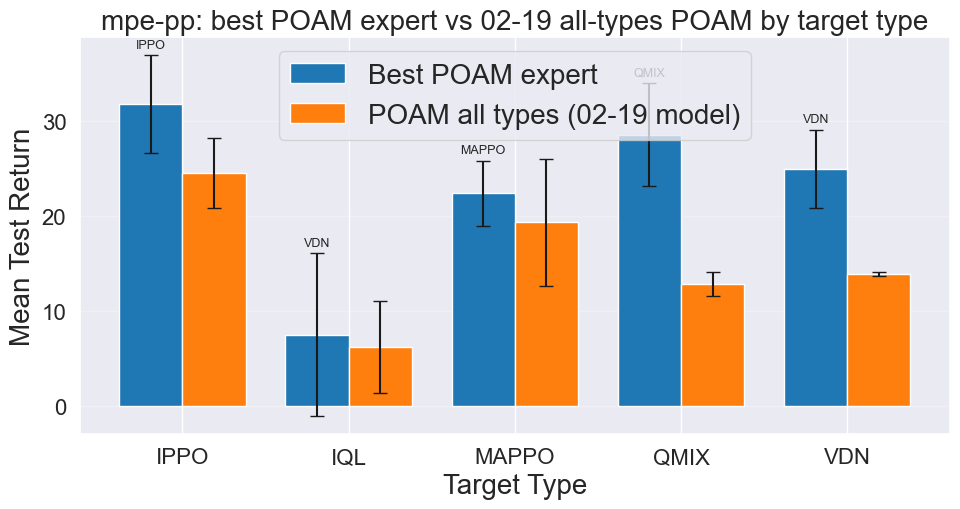

In [14]:
from pathlib import Path
import json

task = "mpe-pp"
n_total = 3
expert_display = {
    "ippo": "IPPO expert",
    "qmix": "QMIX expert",
    "vdn": "VDN expert",
    "mappo": "MAPPO expert",
    "iql": "IQL expert",
}
target_display = {
    "ippo": "IPPO",
    "qmix": "QMIX",
    "vdn": "VDN",
    "mappo": "MAPPO",
    "iql": "IQL",
}

def summarize_returns(info_paths):
    returns = []
    for info_path in info_paths:
        with open(info_path, "r") as f:
            info = json.load(f)
        returns.append(info["test_return_mean"][0]["value"])
    returns = np.array(returns, dtype=float)
    std_error = np.std(returns) / np.sqrt(len(returns)) if len(returns) > 1 else 0.0
    return {"mean": float(np.mean(returns)), "ci": float(1.96 * std_error)}, returns.tolist()

base_path_candidates = [
    Path(base_path),
    Path("../") / base_path,
    Path("../../") / base_path,
]
resolved_base_path = next((p for p in base_path_candidates if p.exists()), None)
if resolved_base_path is None:
    raise FileNotFoundError(f"Could not resolve base_path from candidates: {base_path_candidates}")

expert_log_path = resolved_base_path / task / "poam_expert_nk_eval"
poam_all_types_log_path = resolved_base_path / task / "poam_02-19-00-22-08_nk_eval"
if not expert_log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {expert_log_path}")
if not poam_all_types_log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {poam_all_types_log_path}")

comparison_rows = []
for target_name, target_label in target_display.items():
    best_expert_row = None
    for expert_name in expert_display:
        sacred_folder = expert_log_path / f"poam-expert-{expert_name}-vs-{target_name}" / "sacred"
        if not sacred_folder.exists():
            continue
        all_info_paths = [
            sacred_folder / run_name / "1" / "info.json"
            for run_name in os.listdir(sacred_folder)
            if (sacred_folder / run_name / "1" / "info.json").exists()
        ]
        if not all_info_paths:
            continue
        summary, returns = summarize_returns([str(p) for p in all_info_paths])
        row = {
            "target": target_label,
            "best_expert": expert_display[expert_name],
            "best_expert_mean": summary["mean"],
            "best_expert_ci": summary["ci"],
            "best_expert_n": len(returns),
        }
        if best_expert_row is None or row["best_expert_mean"] > best_expert_row["best_expert_mean"]:
            best_expert_row = row

    sacred_folder = poam_all_types_log_path / f"poam_02-19-00-22-08-vs-{target_name}" / "sacred"
    if not sacred_folder.exists():
        continue
    poam_all_types_info_paths = [
        sacred_folder / run_name / "1" / "info.json"
        for run_name in os.listdir(sacred_folder)
        if (sacred_folder / run_name / "1" / "info.json").exists()
    ]
    if not poam_all_types_info_paths or best_expert_row is None:
        continue
    poam_all_types_summary, poam_all_types_returns = summarize_returns([str(p) for p in poam_all_types_info_paths])

    best_expert_row["all_types_poam_mean"] = poam_all_types_summary["mean"]
    best_expert_row["all_types_poam_ci"] = poam_all_types_summary["ci"]
    best_expert_row["all_types_poam_n"] = len(poam_all_types_returns)
    comparison_rows.append(best_expert_row)

if not comparison_rows:
    raise RuntimeError("No overlapping POAM expert and all-types POAM results found")

comparison_df = pd.DataFrame(comparison_rows).sort_values("target").reset_index(drop=True)
# display(comparison_df[["target", "best_expert", "best_expert_mean", "best_expert_ci", "all_types_poam_mean", "all_types_poam_ci"]].round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comparison_df))
width = 0.38
ax.bar(x - width/2, comparison_df["best_expert_mean"], width, yerr=comparison_df["best_expert_ci"], capsize=5, label="Best POAM expert", color="tab:blue")
ax.bar(x + width/2, comparison_df["all_types_poam_mean"], width, yerr=comparison_df["all_types_poam_ci"], capsize=5, label="POAM all types (02-19 model)", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["target"])
ax.set_ylabel("Mean Test Return")
ax.set_xlabel("Target Type")
ax.set_title(f"{task}: best POAM expert vs 02-19 all-types POAM by target type")
ax.grid(axis="y", alpha=0.25)
ax.legend()

for idx, row in comparison_df.iterrows():
    ax.text(x[idx] - width/2, row["best_expert_mean"] + row["best_expert_ci"] + 0.5, row["best_expert"].replace(" expert", ""), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


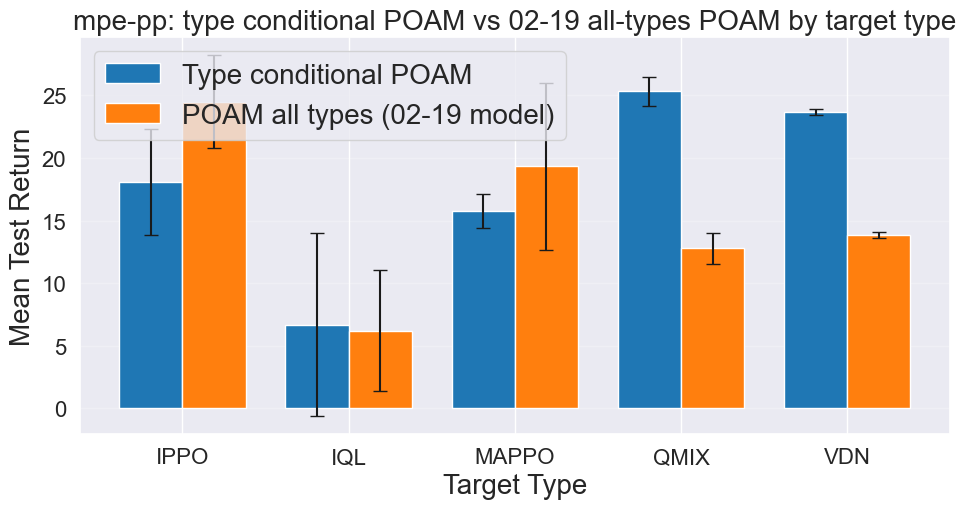

In [16]:
from pathlib import Path
import json
import re

task = "mpe-pp"
n_total = 3
target_display = {
    "ippo": "IPPO",
    "qmix": "QMIX",
    "vdn": "VDN",
    "mappo": "MAPPO",
    "iql": "IQL",
}

def summarize_returns(info_paths):
    returns = []
    for info_path in info_paths:
        with open(info_path, "r") as f:
            info = json.load(f)
        returns.append(info["test_return_mean"][0]["value"])
    returns = np.array(returns, dtype=float)
    std_error = np.std(returns) / np.sqrt(len(returns)) if len(returns) > 1 else 0.0
    return {"mean": float(np.mean(returns)), "ci": float(1.96 * std_error)}, returns.tolist()

def is_adaptive_type_conditional_run(run_folder):
    config_path = run_folder / "1" / "config.json"
    if not config_path.exists():
        return False
    with open(config_path, "r") as f:
        config = json.load(f)

    trained_agents = config.get("trained_agents", {})
    return any(
        agent_cfg.get("agent_loader") == "type_conditional_loader"
        and agent_cfg.get("n_agents_to_populate", 0) >= n_total
        for agent_cfg in trained_agents.values()
    )

def collect_type_conditional_info_paths(log_path, target_name, target_label):
    sacred_folder = log_path / f"type_conditional-vs-{target_name}" / "sacred"
    rows = []
    info_paths = []
    if not sacred_folder.exists():
        return rows, info_paths

    for run_folder in sorted(sacred_folder.iterdir()):
        info_path = run_folder / "1" / "info.json"
        if not info_path.exists() or not is_adaptive_type_conditional_run(run_folder):
            continue

        k_match = re.search(r"_n-(\d+)", run_folder.name)
        k = int(k_match.group(1)) if k_match else np.nan
        rows.append({
            "source": "Type conditional",
            "target": target_label,
            "k": k,
            "n_controlled_agents": n_total - k if not pd.isna(k) else np.nan,
            "run_name": run_folder.name,
        })
        info_paths.append(info_path)
    return rows, info_paths

def collect_poam_all_types_info_paths(log_path, target_name, target_label):
    sacred_folder = log_path / f"poam_02-19-00-22-08-vs-{target_name}" / "sacred"
    rows = []
    info_paths = []
    if not sacred_folder.exists():
        return rows, info_paths

    for run_folder in sorted(sacred_folder.iterdir()):
        info_path = run_folder / "1" / "info.json"
        if not info_path.exists() or not run_folder.name.startswith("eval_poam-"):
            continue

        k_match = re.search(r"_n-(\d+)", run_folder.name)
        k = int(k_match.group(1)) if k_match else np.nan
        rows.append({
            "source": "POAM all types",
            "target": target_label,
            "k": k,
            "n_controlled_agents": n_total - k if not pd.isna(k) else np.nan,
            "run_name": run_folder.name,
        })
        info_paths.append(info_path)
    return rows, info_paths

base_path_candidates = [
    Path(base_path),
    Path("../") / base_path,
    Path("../../") / base_path,
]
resolved_base_path = next((p for p in base_path_candidates if p.exists()), None)
if resolved_base_path is None:
    raise FileNotFoundError(f"Could not resolve base_path from candidates: {base_path_candidates}")

type_conditional_log_path = resolved_base_path / task / "type_conditional_nk_eval"
poam_all_types_log_path = resolved_base_path / task / "poam_02-19-00-22-08_nk_eval"
if not type_conditional_log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {type_conditional_log_path}")
if not poam_all_types_log_path.exists():
    raise FileNotFoundError(f"Missing evaluation folder: {poam_all_types_log_path}")

comparison_rows = []
run_rows = []
for target_name, target_label in target_display.items():
    type_rows, type_info_paths = collect_type_conditional_info_paths(
        type_conditional_log_path,
        target_name,
        target_label,
    )
    poam_rows, poam_info_paths = collect_poam_all_types_info_paths(
        poam_all_types_log_path,
        target_name,
        target_label,
    )
    run_rows.extend(type_rows)
    run_rows.extend(poam_rows)

    if not type_info_paths or not poam_info_paths:
        continue

    type_summary, type_returns = summarize_returns(type_info_paths)
    poam_summary, poam_returns = summarize_returns(poam_info_paths)
    comparison_rows.append({
        "target": target_label,
        "type_conditional_mean": type_summary["mean"],
        "type_conditional_ci": type_summary["ci"],
        "type_conditional_n": len(type_returns),
        "poam_all_types_mean": poam_summary["mean"],
        "poam_all_types_ci": poam_summary["ci"],
        "poam_all_types_n": len(poam_returns),
    })

if not comparison_rows:
    raise RuntimeError("No overlapping type-conditional and POAM all-types N-k results found")

runs_df = pd.DataFrame(run_rows).sort_values(["target", "source", "n_controlled_agents", "run_name"])
# display(runs_df)

comparison_df = pd.DataFrame(comparison_rows).sort_values("target").reset_index(drop=True)
# display(comparison_df.round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comparison_df))
width = 0.38
ax.bar(
    x - width / 2,
    comparison_df["type_conditional_mean"],
    width,
    yerr=comparison_df["type_conditional_ci"],
    capsize=5,
    label="Type conditional POAM",
    color="tab:blue",
)
ax.bar(
    x + width / 2,
    comparison_df["poam_all_types_mean"],
    width,
    yerr=comparison_df["poam_all_types_ci"],
    capsize=5,
    label="POAM all types (02-19 model)",
    color="tab:orange",
)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["target"])
ax.set_ylabel("Mean Test Return")
ax.set_xlabel("Target Type")
ax.set_title(f"{task}: type conditional POAM vs 02-19 all-types POAM by target type")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


